In [1]:
import numpy as np  # Import NumPy for numerical operations
import pandas as pd  # Import Pandas for data manipulation
import tensorflow as tf  # Import TensorFlow for building neural network models
import seaborn as sns  # Import Seaborn for statistical plotting
import matplotlib.pyplot as plt  # Import Matplotlib for creating plots
from sklearn.model_selection import train_test_split  # Import train_test_split for splitting datasets
from sklearn.metrics import mean_squared_error, r2_score  # Import metrics for evaluating models
from sklearn.linear_model import LinearRegression, HuberRegressor, ElasticNet  # Import linear regression models
from sklearn.decomposition import PCA  # Import PCA for dimensionality reduction
from sklearn.cross_decomposition import PLSRegression  # Import PLSRegression for partial least squares regression
from sklearn.preprocessing import SplineTransformer  # Import SplineTransformer for spline feature transformation
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor  # Import ensemble regression models

In [2]:
n_stocks = 10  # Define the number of stocks
n_months = 24  # Define the number of months (time periods)
n_characteristics = 5  # Define the number of stock-specific characteristics
n_macro_factors = 3  # Define the number of macroeconomic factors

np.random.seed(42)  # Set the random seed for reproducibility
stock_characteristics = np.random.rand(n_stocks, n_months, n_characteristics)  # Generate random stock characteristic data
macro_factors = np.random.rand(n_months, n_macro_factors)  # Generate random macroeconomic factor data

In [3]:
zi_t = np.zeros((n_stocks,n_months, n_characteristics * n_macro_factors))
for t in range(n_months):
    for i in range(n_stocks):
        outer_prod = np.outer(macro_factors[t], stock_characteristics[i, t],) # 3 x 5 = 15
        zi_t[i, t] = outer_prod.flatten()
zi_t

array([[[2.83999988e-01, 7.20891668e-01, 5.55044066e-01, ...,
         1.61943057e-02, 1.32444518e-02, 3.45168643e-03],
        [5.04814209e-02, 1.87964505e-02, 2.80303452e-01, ...,
         6.67308528e-01, 4.63103464e-01, 5.45504366e-01],
        [1.40652898e-02, 6.62734918e-01, 5.68804208e-01, ...,
         2.27778505e-01, 5.81016430e-02, 4.97521596e-02],
        ...,
        [1.13482846e-01, 1.86814575e-01, 3.43942102e-01, ...,
         5.47373286e-02, 1.65757150e-02, 5.57695489e-03],
        [1.13725578e-01, 6.32783164e-02, 3.64900338e-01, ...,
         5.57837695e-01, 4.84888833e-01, 3.80055269e-01],
        [2.54172443e-01, 2.34401070e-01, 5.44155045e-02, ...,
         1.60473086e-01, 7.67709985e-01, 4.63900342e-01]],

       [[6.12252153e-01, 6.79473053e-01, 2.41130331e-01, ...,
         7.03536626e-03, 2.43473942e-03, 5.04273531e-03],
        [1.38216445e-01, 2.64717938e-01, 2.78541213e-01, ...,
         6.63113226e-01, 5.35597293e-03, 3.93483511e-01],
        [2.85215009e-01, 

In [4]:
theta = np.random.rand(n_characteristics * n_macro_factors)
ri_t_plus_1 = np.zeros((n_stocks, n_months))
for t in range(n_months):
    for i in range(n_stocks):
        ri_t_plus_1[i, t] = np.dot(zi_t[i, t], theta) + np.random.normal(0, 0.05) # add noise


In [5]:
zi_t_flattened = zi_t.reshape(n_stocks * n_months, - 1)
ri_t_flattened = ri_t_plus_1.flatten()


In [6]:
stock_ids = np.repeat(np.arange(n_stocks), n_months)
months = np.tile(np.arange(n_months), n_stocks)

df_features_cols = [f"z{i+1}" for i in range(zi_t_flattened.shape[1])]
df_features = pd.DataFrame(zi_t_flattened, columns=df_features_cols)
df_features["Stock ID"] = stock_ids = stock_ids
df_features["Month"] = months = months

df_features

,z1,z2,z3,z4,z5,z6,z7,z8,z9,z10,z11,z12,z13,z14,z15,Stock ID,Month
0,0.284000,0.720892,0.555044,0.453941,0.118303,0.009209,0.023375,0.017997,0.014719,0.003836,0.008286,0.021033,0.016194,0.013244,0.003452,0,0
1,0.050481,0.018796,0.280303,0.194527,0.229140,0.076226,0.028382,0.423251,0.293731,0.345995,0.120179,0.044748,0.667309,0.463103,0.545504,0,1
2,0.014065,0.662735,0.568804,0.145090,0.124240,0.009179,0.432485,0.371188,0.094683,0.081076,0.005632,0.265393,0.227779,0.058102,0.049752,0,2
3,0.182877,0.303367,0.523247,0.430703,0.290392,0.078164,0.129662,0.223641,0.184087,0.124116,0.082786,0.137331,0.236868,0.194974,0.131457,0,3
4,0.100114,0.022825,0.047802,0.059946,0.074624,0.486307,0.110871,0.232199,0.291188,0.362489,0.424431,0.096764,0.202656,0.254139,0.316368,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,0.265454,0.383368,0.052591,0.374117,0.266084,0.034672,0.050073,0.006869,0.048865,0.034754,0.314256,0.453848,0.062260,0.442896,0.315002,9,19
236,0.259038,0.091961,0.170171,0.250709,0.027574,0.768043,0.272663,0.504553,0.743347,0.081758,0.298876,0.106104,0.196342,0.289266,0.031815,9,20
237,0.426645,0.313139,0.030881,0.137005,0.322374,0.010891,0.007994,0.000788,0.003497,0.008229,0.067899,0.049835,0.004915,0.021804,0.051305,9,21
238,0.026435,0.228498,0.135757,0.243705,0.017953,0.032324,0.279406,0.166003,0.298001,0.021953,0.040412,0.349314,0.207537,0.372562,0.027446,9,22


In [7]:
df_returns = pd.DataFrame({"ExcessReturn" : ri_t_flattened,
                           "Stock ID" : stock_ids,
                           "Month" : months,})
df_returns

,ExcessReturn,Stock ID,Month
0,0.630027,0,0
1,1.552710,0,1
2,0.831843,0,2
3,1.315436,0,3
4,1.683045,0,4
...,...,...,...
235,0.904371,9,19
236,2.205843,9,20
237,0.487068,9,21
238,0.849218,9,22


In [8]:
df_model = pd.merge(df_features, df_returns, on=["Stock ID", "Month"])
df_model

,z1,z2,z3,z4,z5,z6,z7,z8,z9,z10,z11,z12,z13,z14,z15,Stock ID,Month,ExcessReturn
0,0.284000,0.720892,0.555044,0.453941,0.118303,0.009209,0.023375,0.017997,0.014719,0.003836,0.008286,0.021033,0.016194,0.013244,0.003452,0,0,0.630027
1,0.050481,0.018796,0.280303,0.194527,0.229140,0.076226,0.028382,0.423251,0.293731,0.345995,0.120179,0.044748,0.667309,0.463103,0.545504,0,1,1.552710
2,0.014065,0.662735,0.568804,0.145090,0.124240,0.009179,0.432485,0.371188,0.094683,0.081076,0.005632,0.265393,0.227779,0.058102,0.049752,0,2,0.831843
3,0.182877,0.303367,0.523247,0.430703,0.290392,0.078164,0.129662,0.223641,0.184087,0.124116,0.082786,0.137331,0.236868,0.194974,0.131457,0,3,1.315436
4,0.100114,0.022825,0.047802,0.059946,0.074624,0.486307,0.110871,0.232199,0.291188,0.362489,0.424431,0.096764,0.202656,0.254139,0.316368,0,4,1.683045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,0.265454,0.383368,0.052591,0.374117,0.266084,0.034672,0.050073,0.006869,0.048865,0.034754,0.314256,0.453848,0.062260,0.442896,0.315002,9,19,0.904371
236,0.259038,0.091961,0.170171,0.250709,0.027574,0.768043,0.272663,0.504553,0.743347,0.081758,0.298876,0.106104,0.196342,0.289266,0.031815,9,20,2.205843
237,0.426645,0.313139,0.030881,0.137005,0.322374,0.010891,0.007994,0.000788,0.003497,0.008229,0.067899,0.049835,0.004915,0.021804,0.051305,9,21,0.487068
238,0.026435,0.228498,0.135757,0.243705,0.017953,0.032324,0.279406,0.166003,0.298001,0.021953,0.040412,0.349314,0.207537,0.372562,0.027446,9,22,0.849218


In [9]:
X = df_model[[f"z{i+1}" for i in range(zi_t_flattened.shape[1])]]
y = df_model["ExcessReturn"]

# Split
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.28571, random_state=42) # 0.7 * 0.28571 = 0.2 -> 20% for validation


In [10]:
# -------------------------------
# Part 3: Model Training Section
# -------------------------------

# --- OLS Regression ---
# 1. Initialize and trainm the model
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

# 2. Predict
y_train_pred = ols_model.predict(X_train)
y_test_pred = ols_model.predict(X_test)

# 3. Evaluate the performance
print("OLS regression performance:")
print(f"Train R^2: {r2_score(y_train, y_train_pred):.4f}")
print(f"Test R^2: {r2_score(y_test, y_test_pred):.4f}")
print(f"Train MSE: {mean_squared_error(y_train, y_train_pred):.4f}")



OLS regression performance:
Train R^2: 0.9945
Test R^2: 0.9968
Train MSE: 0.0027


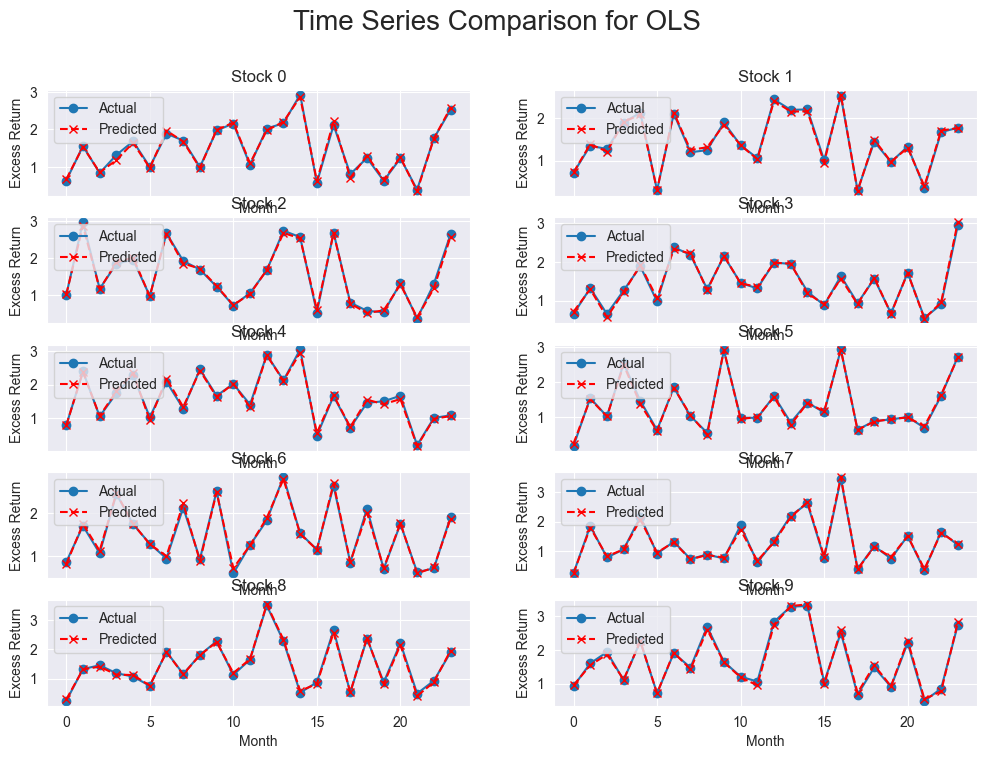

In [11]:
y_pred_all = ols_model.predict(X)
def plot_comparison_per_stock(suptitle: str, X_all, y_pred):
    fig, ax = plt.subplots(5, 2, figsize=(12, 8), sharex=True)
    ax = ax.flatten()
    fig.suptitle(suptitle, fontsize=20)
    for i in range(n_stocks):
        df = X_all[X_all["Stock ID"] == i].sort_values("Month")
        ax[i].plot(df["Month"], df["ExcessReturn"], marker='o', linestyle='-', label='Actual')
        ax[i].plot(df["Month"], y_pred[df.index], marker='x', linestyle='--', color='red', label='Predicted')

        ax[i].set_title(f"Stock {i}")
        ax[i].set_xlabel("Month")
        ax[i].set_ylabel("Excess Return")
        ax[i].legend(loc='upper left')


    plt.show()
plot_comparison_per_stock("Time Series Comparison for OLS", df_model, y_pred_all)


In [12]:
# --- Weighted Linear Regression ---
weights = np.random.rand(len(df_model)) + 0.5 # Avoid zero weights
def fit_weighted_linear_regression(X,y,w):
    weights = np.diag(w)  # Diagonal weight matrix
    XTWX = X.T @ weights @ X
    XTWy = X.T @ weights @ y
    theta = np.linalg.inv(XTWX) @ XTWy

    return theta

def predict_weighted_linear_regression(X,theta):
    return X @ theta


In [13]:
df_wls = pd.DataFrame(zi_t_flattened, columns=[f"z_{k + 1}" for k in range(zi_t_flattened.shape[1])])
df_wls["Excess_Return"] = ri_t_flattened
df_wls["weights"] = np.random.rand(n_stocks * n_months) +0.5 # avoid zero weights

# split into train and test (preserving weights)
train_data, test_data = train_test_split(df_wls, test_size=0.3, random_state=42)

# extract predictor matrix, target vector, and sample weights
X_train = train_data.drop(columns=["Excess_Return", "weights"]).values
y_train = train_data["Excess_Return"].values
w_train = train_data["weights"].values

X_test  = test_data.drop(columns=["Excess_Return", "weights"]).values
y_test  = test_data["Excess_Return"].values
w_test  = test_data["weights"].values

# fit weighted least squares and predict
theta = fit_weighted_linear_regression(X_train, y_train, w_train)
y_pred_wls = predict_weighted_linear_regression(X_test, theta)

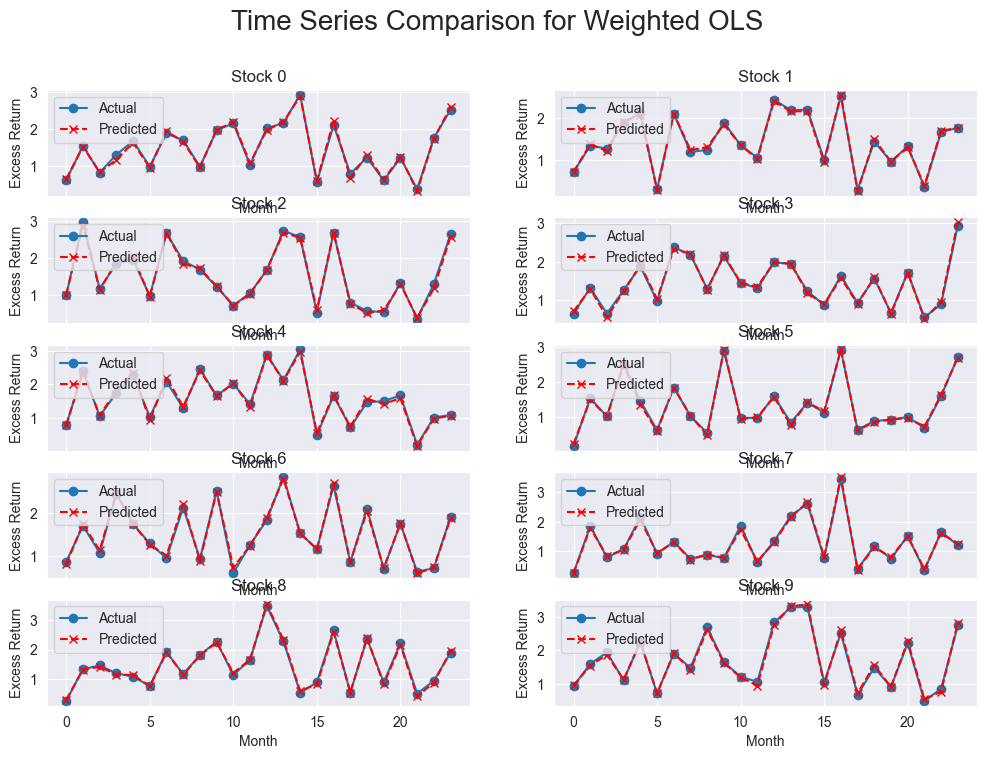

In [14]:
# compute WLS predictions for all observations
y_pred_wls_all = predict_weighted_linear_regression(X, theta)

# plot actual vs. weighted‐OLS predicted per stock using y_pred_wls_all

plot_comparison_per_stock("Time Series Comparison for Weighted OLS", df_model, y_pred_wls_all)